### 1.라이브러리 호출

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

### 2.CPU 혹은 GPU 장치 확인

In [30]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# 하나의 GPU 사용할 때
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = Net()
model.to(device)

# 다수의 GPU 사용할 때 : nn.DataParallel - 배치 크기가 알아서 각 GPU로 분배되는 방식으로 작동. GPU수 만큼 배치 크기도 늘려주어야함
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net()
if torch.cuda.device_count() > 1:
  model = nn.DataParallel(net)
model.to(device)


### 3.fashion_mnist 데이터셋 내려받기

In [11]:
train_dataset = torchvision.datasets.FashionMNIST(
    "../chap05/data", # FasionMNIST 내려받을 위치
    download=True, # 첫번째 파라미터의 위치에 해당 데이터셋이 있는지 확인 후 내려받음
    transform=transforms.Compose([transforms.ToTensor()]) # 이미지를 텐서(0~1)로 변경
)

test_dataset = torchvision.datasets.FashionMNIST(
    "../chap05/data",
    download=True,
    train=False,
    transform=transforms.Compose([transforms.ToTensor()])
)

### 4.fasion_mnist 데이터를 데이터로더에 전달

In [12]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, # 데이터로 불러올 데이터셋 지정
    batch_size=100) # 데이터를 배치 단위로 묶어줌

test_loader = torch.utils.data.DataLoader(
    test_dataset, # 데이터로 불러올 데이터셋 지정
    batch_size=100) # 데이터를 배치 단위로 묶어줌

In [20]:
images, labels = next(iter(train_loader))
print(images.size())
print(labels.size())

torch.Size([100, 1, 28, 28])
torch.Size([100])


### 5.분류에 사용될 클래스 정의

- np.random : 무작위 데이터 생성
- np.random.randint(len(train_dataset) : 0~(train_dataset의 길이)값을 갖는 분포에서 랜덤한 숫자 한 개를 생성

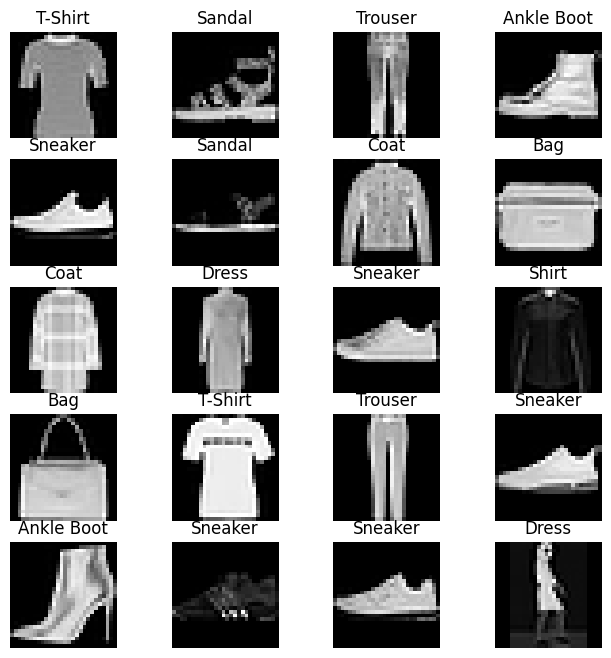

In [21]:
labels_map = {0:'T-Shirt',1 :'Trouser',2:'Pullover',3:'Dress',4:'Coat',5:'Sandal',6:'Shirt',7:'Sneaker',8:'Bag',9:'Ankle Boot'}

fig = plt.figure(figsize=(8,8));
columns=4;
rows = 5;

for i in range(1, columns*rows+1):

  img_xy = np.random.randint(len(train_dataset));
  img = train_dataset[img_xy][0][0,:,:]

  fig.add_subplot(rows,columns,i)

  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img,cmap='gray')

plt.show()

### 6.심층 신경망 모델 생성

##### 객체
- 객체 지향 프로그래밍(object oriented programming)
  - 프로그래밍에서 필요한 데이터를 추상화하여 속성이나 행동, 동작, 특징 등을 객체로 만들고, 그 객체들이 서로 유기적으로 동작하도록 하는 프로그래밍 방법
  - 클래스라는 붕어빵 틀에서 여러 개의 객체(팥붕, 슈붕)라는 붕어빵을 찍어 내는 것과 같은
  - 재사용성의 이유로 객체 지향 프로그래밍을 많이 사용하고 있음
- 객체(object)
  - 메모리를 할당받아 프로그램에서 사용되는 모든 데이터
  - 변수, 함수 등은 모두 객체
  - 객체명 = 클래스명()
---
##### 클래스와 함수
- 함수(function)란 하나의 특정 작업을 수행하기 위해 독립적으로 설계된 프로그램 코드
  - 함수의 호출은 특정 작업만 수행할 뿐 그 결괏값을 계속 사용하기 위해서는 반드시 어딘가에 따로 그 값을 저장해야함
  - 즉, 함수를 포함한 프로그램 코드의 일부를 재사용하기 위해서는 해당 함수뿐만 아니라 데이터가 저장되는 변수까지도 한꺼번에 관리해야함
- 클래스(Class)란 이처럼 함수뿐만 아니라 관련된 변수까지도 한꺼번에 묶어서 관리하고 재사용할 수 있게 해주는 것


In [23]:
# 함수
def add(num1,num2):
  result = num1 + num2
  return result

print(add(1,2))
print(add(2,3))

3
5


In [24]:
# 클래스
class Calc:
  def __init__(self):
    self.result = 0

  def add(self, num1, num2):
    self.result = num1 + num2
    return self.result

obj1 = Calc()
obj2 = Calc()

print(obj1.add(1,2))
print(obj1.add(2,3))
print('-------------')
print(obj2.add(2,3))
print(obj2.add(2,3))

3
5
-------------
5
5


In [38]:
class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN,self).__init__()
        self.fc1 = nn.Linear(in_features=784,out_features=256)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=256,out_features=128)
        self.fc3 = nn.Linear(in_features=128,out_features=10)

    def forward(self,input_data):
        out = input_data.view(-1, 784)
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

- **def __init__(self)** : 클래스 형태의 모델은 항상 torch.nn.Module 상속 받음
  - __init__(self) : 객체가 갖는 속성 값을 초기화하는 역할을 하며, 객체가 생성될 때 자동으로 호출됨
  - super(FashionDNN, self).__init__() : FasionDNN이라는 부모(super) 클래스를 상속받겠다는 의미
---
- **nn** : 딥러닝 모델(네트워크) 구성에 필요한 모듈이 모여 있는 패키지
  - (ex) Linear는 단순 선형 회귀 모델을 만들 때 사용
    - nn.Linear(in_features,out_features)
      - in_features : 입력 크기(input_size)
      - out_features : 출력 크기(output_size)
---
- **forward()** : 실제로 데이터 연산이 진행되는 부분
  - 첫번째 파라미터 값만 넘겨줌
  - 두번째 파라미터에서 정의된 크기가 forward() 연산의 결과가 됨
---
- **torch.nn.Dropout(p)** : p만큼의 비율로 텐서의 값이 0이 되고, 0이 되지 않는 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐
  (ex) p=0.3은 전체 값 중 0.3활률로 0이 됨을 의미 -> 0이 되지 않는 0.7에 해당하는 값은 (1/(1-0.3))만큼 커짐
---
- **forward()** : 모델이 학습 데이터를 입력받아서 순전파 학습을 진행시킴 -> 반드시 이름이 forward라는 이름의 함수여야 함
  - forward()는 모델이 학습 데이터를 입력받아서 순전파 연산을 진행하는 함수이며, 객체를 데이터와 함께 호출하면 자동으로 실행됨
---
- **view()** : 넘파이의 reshape과 같은 역할 -> 텐서의 크기(shape)를 변경해 주는 역할
  - input.data.view(-1,784)는 input data를(?,784)크기로 바꾸라는 의미
    - -1은 2번째 차원 784에 맞게 파이토치가 변경하라는 의미

#### 활성화 함수를 지정하는 방법
  - (1) F.relu() : forward()함수에서 정의
  - (2) nn.ReLU() : __init__() 함수에서 정의
---
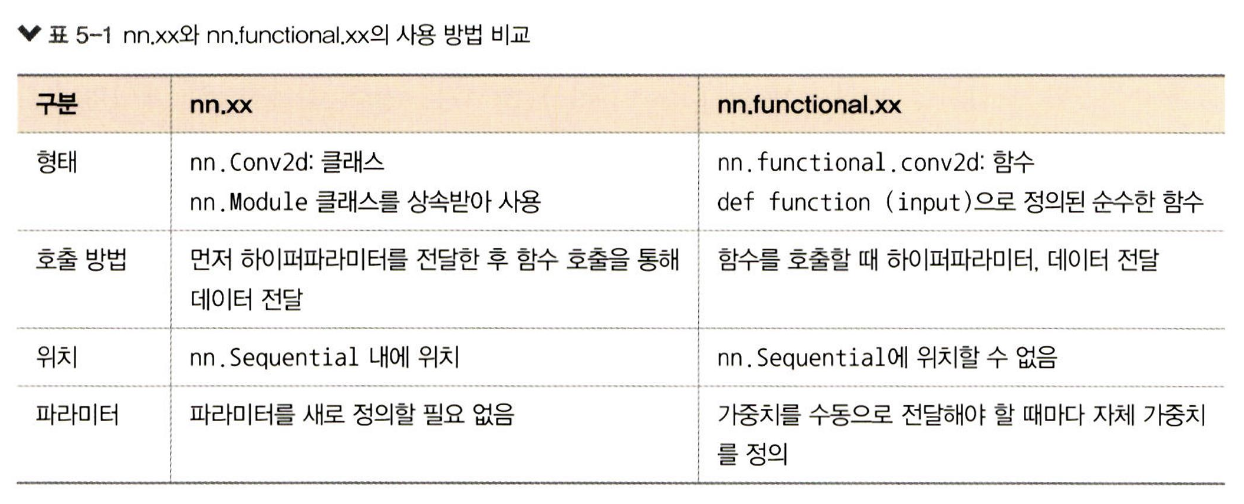

##### init()함수에서 정의하는 nn을 사용하는 코드

In [25]:
# init() 함수에서 정의하는 nn을 사용하는 코드
import torch
import torch.nn as nn

inputs = torch.randn(64,3,244,244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
# 3개의 채널이 입력되어 64개의 채널이 출력되기 위한 연산으로 3X3 크기의 커널을 사용
outputs = conv(inputs)
layer = nn.Conv2d(1,1,3)

##### forward() 함수에서 정의하는 nn.functional을 사용하는 코드
- nn.Conv2d에서 input_channel과 output_channel을 사용해서 연산했다면,
- funtional.conv2d는 input과 weight 자체를 직접 넣어줌
  - 직접 넣어준다는 것은 가중치를 전달해야할 때마다 가중치 값을 새로 정의해야함을 의미
- torch.randn(출력 채널 수, 입력 채널 수, 커널 높이, 커널 너비)


In [26]:
# forward() 함수에서 정의하는 nn.functional을 사용하는 코드
import torch.nn.functional as F

inputs = torch.randn(64,3,244,244)
weight =torch.randn(64,3,3,3)
bias = torch.randn(64)
outputs = F.conv2d(inputs,weight,bias,padding=1)

##### nn.Sequential 사용해서 코드 개선

### 7.심층 신경망에서 필요한 파라미터 정의

In [39]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


### 8.심층 신경망을 이용한 모델 학습

In [42]:
num_epochs = 5
count = 0

# 학습 중간 중간의 loss, 반복 횟수, 정확도 기록용
loss_list = []
iteration_list = []
accuracy_list = []

# 예측값과 실제 정답 저장용
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader: # 학습 데이터를 배치 단위로 꺼냄
        images, labels = images.to(device), labels.to(device) # 데이터를 GPU로 이동

        train = Variable(images.view(100, 1, 28, 28)) # 이미지의 크기를 바꿔줌
        labels = Variable(labels)

        outputs = model(train) # 모델에 이미지를 넣어서 예측값(outputs) 얻음
        loss = criterion(outputs, labels) # 손실 계산
        optimizer.zero_grad() # 이전 step에서 계산된 gradient(기울기) 초기화
        loss.backward() # 역전파 수행
        optimizer.step() # 계산된 gradient 이용해서 모델 weight 업데이트
        count += 1

        if not (count % 50): # 매 50번 반복마다 테스트 정확도 계산
            total = 0
            correct = 0
            for images, labels in test_loader: # 배치 단위로 테스트 데이터 불러옴
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels) # 정답 라벨 저장
                test = Variable(images.view(100, 1, 28, 28)) # 테스트 이미지도 모델 입력 형태로 reshape
                outputs = model(test) # 모델에 테스트 이미지 넣고 예측값 얻기
                predictions = torch.max(outputs, 1)[1].to(device) # 예측값에서 가장 높은 점수를 가진 클래스의 인덱스를 예측값으로 선택
                predictions_list.append(predictions) # 예측값 저장
                correct += (predictions == labels).sum() # 맞춘 개수 더하기
                total += len(labels) # 전체 샘플 수 더하기

            accuracy = correct * 100 / total
            # 시각화 용도로 현재 손실, 반복 횟수, 정확도를 리스트에 저장
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500): # 500번마다 중간 결과 출력
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.4336899518966675, Accuracy: 86.5%
Iteration: 1000, Loss: 0.41836559772491455, Accuracy: 85.91999816894531%
Iteration: 1500, Loss: 0.2955875098705292, Accuracy: 87.2699966430664%
Iteration: 2000, Loss: 0.26051804423332214, Accuracy: 86.4800033569336%
Iteration: 2500, Loss: 0.2063811868429184, Accuracy: 86.68000030517578%
Iteration: 3000, Loss: 0.2184866964817047, Accuracy: 87.91999816894531%


### 9.합성곱 네트워크 생성

- **nn.Sequential()**
  - 계층을 차례로 쌓을 수 있도록 Ws+ 6 와 같은 수식과 활성
화 함수를 연결해 주는 역할
  - 데이터가 각 계층을 순차적으로 지나갈 때 사용하면
좋은 방법
  - **여러 개의 계층을 하나의 컨테이너에 구현하는 방법**
---
- **nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)**
  - in_channels: 입력 채널의 수 -> 흑백 이미지는 1, RGB 값을 가진 이미지는3
  - out_channels: 출력 채널의 수
  - kernel_size: 커널(필터) 크기
    - 커널은 이미지 특징을 찾아내기 위한 공용 파라미터
    - CNN에서 학습 대상은 커널(필터) 파라미터
    - 커널은 입력 데이터를 스트라이드 간격으로 순회하면서 합성곱을 계산
  - padding: 패딩 크기
    - 출력 크기를 조정하기 위해 입력 데이터 주위에 0을 채움 -> 패딩 값이 클수록 출력 크기도 커짐
---
- **BatchNorm2d**
  - 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균
과 분산을 이용하여 정규화하는 것
  - 평균은 0, 표준편차는 1로 데이터의 분포가 조정됨
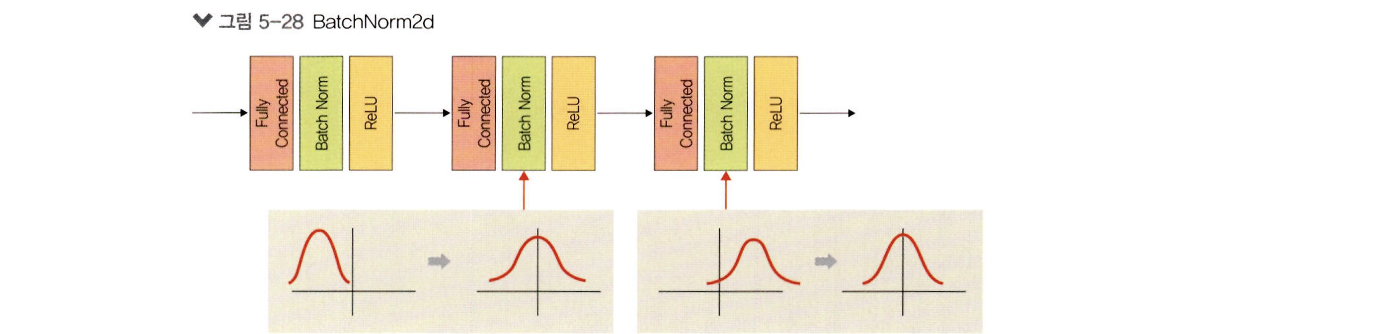
---
- **MaxPool2d(kernel_size=2, stride=2)**
  - 풀링 계층은 합성곱층의 출력데이터를 입력으로 받아서 출력 데이터(activation map)의 크기를 줄이거나 특정 데이터를 강조하는 용도
  - max pooling, average pooling


In [46]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN,self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self,x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0),-1)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

##### ```out = self.layer1(x)```
- 1채널 (흑백) 이미지 → **Conv2d(1→32)** 로 특징 추출
- `BatchNorm + ReLU + MaxPool` 통해서 **노이즈 줄이고**, **중요 특징만 강조**
- 출력 크기 줄어듦 (28x28 → 14x14)

---

##### ```out = self.layer2(out)```
- **더 깊은 특징** 추출 (예: 가장자리 → 패턴 → 물체 등)
- Conv2d(32→64), MaxPool 한 번 더 → 크기 더 줄어듦 (14x14 → 6x6)

---

##### ```out = out.view(out.size(0), -1)```
- CNN 레이어를 지나면 **이미지는 텐서(3차원)** 형태로 남아 있음
- Fully Connected Layer (`fc1`)에 넣으려면 **1D 벡터로 펴줘야 함**.
- 예: `(batch_size, 64, 6, 6)` → `(batch_size, 64*6*6)` = `(batch_size, 2304)`

---

##### ```out = self.fc1(out)```
- 이미지의 추상적인 특징 벡터 → **600차원 표현**으로 줄여줌
- 여기서부터는 **MLP 구조 (Fully Connected Network)** 로 진행됨
- 클래스를 분류하기 위해서는 이미지 형태의 데이터를 배열 형태로 변환하여 작업해야함
  - 이때 Conv2d 에서 사용하는 하이퍼파라미터 값들에 따라 출력 크기 (output size)가 달라짐
  - 즉 , 패딩과 스트라이드의 값에 따라 출력 크기가 달라짐
  - 이렇게 줄어든 출력 크기는 최종적으로 분류를 담당하는 완전연결 (fully connected layer)으로 전달

---

##### ```out = self.drop(out)```
- 학습할 때 **과적합을 방지**하기 위해 Dropout을 적용.
- 일부 뉴런을 랜덤하게 끊어서 **일반화 성능을 높임**.

---

##### ```out = self.fc2(out)```  
- 600 → 120 차원으로 한 번 더 축소.  
- 더 추상적인 정보로 압축.

---

##### ```out = self.fc3(out)```  
- 최종 출력층. 클래스 수가 10이니까 `Linear(120 → 10)`
- 예: `FashionMNIST`의 10개 의류 종류 분류

---

##### ```return out```  
- 최종 결과는 **10개의 클래스 점수 (logits)**  
- 이건 나중에 `CrossEntropyLoss`에 들어가서 **Softmax + Loss 계산**됨.

---
##### **CNN 구조의 공식 루틴**

1. **Conv 블록들** → 공간 정보에서 의미 추출
2. **Flatten** → 벡터화
3. **FC 레이어들** → 추상적 특징을 바탕으로 의사 결정
4. **Dropout 등** → 일반화 도와줌
5. **출력층** → 클래스 수만큼 출력

### 10.합성곱 네트워크를 위한 파라미터 정의

In [47]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


### 11.모델 학습 및 성능 평가
- 심층 신경망과 비교하여 정확도가 약간 높음
- 심층 신경망과 별 차이가 없기 때문에 좀 더 간편한 심층 신경망만 사용해도 무난할 것 같지만
- 실제로 이미지 데이터가 많아지면 단순 심층 신망으로는 정확한 특성 추출 및 분류가 불가능하므로 합성곱 신경망을 생성할 수 있도록 학습해야함

In [50]:
num_epochs = 5
count = 0

# 학습 중간 중간의 loss, 반복 횟수, 정확도 기록용
loss_list = []
iteration_list = []
accuracy_list = []

# 예측값과 실제 정답 저장용
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader: # 학습 데이터를 배치 단위로 꺼냄
        images, labels = images.to(device), labels.to(device) # 데이터를 GPU로 이동

        train = Variable(images.view(100, 1, 28, 28)) # 이미지의 크기를 바꿔줌
        labels = Variable(labels)

        outputs = model(train) # 모델에 이미지를 넣어서 예측값(outputs) 얻음
        loss = criterion(outputs, labels) # 손실 계산
        optimizer.zero_grad() # 이전 step에서 계산된 gradient(기울기) 초기화
        loss.backward() # 역전파 수행
        optimizer.step() # 계산된 gradient 이용해서 모델 weight 업데이트
        count += 1

        if not (count % 50): # 매 50번 반복마다 테스트 정확도 계산
            total = 0
            correct = 0
            for images, labels in test_loader: # 배치 단위로 테스트 데이터 불러옴
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels) # 정답 라벨 저장
                test = Variable(images.view(100, 1, 28, 28)) # 테스트 이미지도 모델 입력 형태로 reshape
                outputs = model(test) # 모델에 테스트 이미지 넣고 예측값 얻기
                predictions = torch.max(outputs, 1)[1].to(device) # 예측값에서 가장 높은 점수를 가진 클래스의 인덱스를 예측값으로 선택
                predictions_list.append(predictions) # 예측값 저장
                correct += (predictions == labels).sum() # 맞춘 개수 더하기
                total += len(labels) # 전체 샘플 수 더하기

            accuracy = correct * 100 / total
            # 시각화 용도로 현재 손실, 반복 횟수, 정확도를 리스트에 저장
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500): # 500번마다 중간 결과 출력
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.13637739419937134, Accuracy: 90.94000244140625%
Iteration: 1000, Loss: 0.18656028807163239, Accuracy: 89.87000274658203%
Iteration: 1500, Loss: 0.09330420196056366, Accuracy: 89.66000366210938%
Iteration: 2000, Loss: 0.13116003572940826, Accuracy: 90.11000061035156%
Iteration: 2500, Loss: 0.08369599282741547, Accuracy: 89.81999969482422%
Iteration: 3000, Loss: 0.10299444943666458, Accuracy: 89.94999694824219%
